<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA3/PROYECTOFINAL/Copia_de_GraphNeuralNetworks_TWITCH_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Neural Network - Proyecto 3

Las redes de jugadores de Twitch se presentaron en el artículo "Integración de nodos atribuidos a múltiples escalas" . Los nodos representan a los jugadores en Twitch y los bordes representan los seguidores entre ellos. Las características de los nodos representan las incrustaciones de los juegos jugados por los usuarios de Twitch. La tarea consiste en predecir si un usuario transmite contenido para adultos.

**Integrantes:**

- Luis Alejandro Garzón Ramirez
- Zorayda Acevedo Jimenez
- Yulieth Danitza Aguillón Ortega

## Install and import packages

In [1]:
!pip install torch-geometric
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install pyg_lib --no-index -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 48.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 60.1 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 3.4 MB/s eta 0:00:00


In [2]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

## Cargar los datos de Pythorch datasets

Carga y normalización de datos



In [4]:
!pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html

from torch_geometric.datasets import Twitch
from torch_geometric.transforms import NormalizeFeatures
import torch
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

# Cargar dataset Twitch (por ejemplo, la red de Alemania: 'DE')
dataset = Twitch(root='data/Twitch', name='DE', transform=NormalizeFeatures()) #normalizacion de datos
data = dataset[0]


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
Processing...
Done!


# Descripcion/entendimientos de los datos - Yulieth

In [5]:
# Print information about the dataset
print(f'Dataset: {dataset}')
print('---------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: Twitch()
---------------
Number of graphs: 1
Number of nodes: 9498
Number of features: 128
Number of classes: 2

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True


Dataset: Twitch()
---------------
Number of graphs: 1
Number of nodes: 9498
Number of edges: 315774
Number of features per node: 128
Number of classes: 2

Graph properties:
------------------
Is directed: False
Has isolated nodes: False
Has self loops: True
Is undirected: True

Class distribution:
 Class 0: 3756 nodes
 Class 1: 5742 nodes

Degree statistics:
 Average degree: 34.25
 Max degree: 4261
 Min degree: 3
 Graph density: 0.003606
 Total number of triangles: 603088
 Average clustering coefficient: 0.2009
 Global transitivity: 0.0465
 Number of connected components: 1
 Largest component size: 9498 nodes

Centrality analysis:
 Top 5 nodes by degree centrality:
  Node 7787: 0.4487
  Node 9206: 0.1924
  Node 2684: 0.1809
  Node 1638: 0.1511
  Node 2914: 0.1431
 Top 5 nodes by betweenness centrality:
  Node 7787: 0.2912
  Node 9206: 0.0798
  Node 2684: 0.0418
  Node 1638: 0.0311
  Node 2914: 0.0270


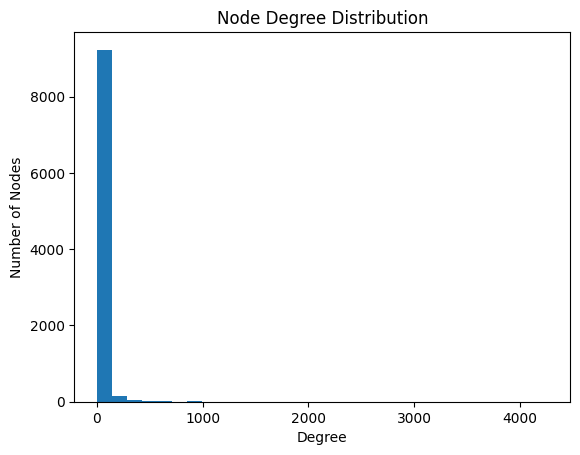

 Global efficiency: 0.3891


In [6]:
from collections import Counter
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# Conversión a NetworkX
G = to_networkx(data, to_undirected=True)

# Información general
print(f'Dataset: {dataset}')
print('---------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Number of features per node: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Propiedades estructurales
print(f'\nGraph properties:')
print('------------------')
print(f'Is directed: {data.is_directed()}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

# Máscaras
for split in ['train_mask', 'val_mask', 'test_mask']:
    if hasattr(data, split):
        mask = getattr(data, split)
        print(f'{split}: {mask.sum().item()} nodes')

# Distribución de clases
print('\nClass distribution:')
class_counts = Counter(data.y.tolist())
for cls, count in class_counts.items():
    print(f' Class {cls}: {count} nodes')

# Grado
degrees = [d for _, d in G.degree()]
print('\nDegree statistics:')
print(f' Average degree: {sum(degrees)/len(degrees):.2f}')
print(f' Max degree: {max(degrees)}')
print(f' Min degree: {min(degrees)}')

# Densidad
density = nx.density(G)
print(f' Graph density: {density:.6f}')

# Triángulos
triangles_dict = nx.triangles(G)
total_triangles = sum(triangles_dict.values()) // 3
print(f' Total number of triangles: {total_triangles}')

# Clustering
avg_clustering = nx.average_clustering(G)
transitivity = nx.transitivity(G)
print(f' Average clustering coefficient: {avg_clustering:.4f}')
print(f' Global transitivity: {transitivity:.4f}')

# Componentes conexas
components = list(nx.connected_components(G))
num_components = len(components)
largest_cc = max(components, key=len)
print(f' Number of connected components: {num_components}')
print(f' Largest component size: {len(largest_cc)} nodes')

# Centralidades
print('\nCentrality analysis:')
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Top 5 nodos por centralidad de grado
top_deg = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print(' Top 5 nodes by degree centrality:')
for node, score in top_deg:
    print(f'  Node {node}: {score:.4f}')

# Top 5 nodos por betweenness
top_bet = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print(' Top 5 nodes by betweenness centrality:')
for node, score in top_bet:
    print(f'  Node {node}: {score:.4f}')

# Visualizar distribución de grado
plt.hist(degrees, bins=30)
plt.title('Node Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()

# Eficiencia global
efficiency = nx.global_efficiency(G)
print(f' Global efficiency: {efficiency:.4f}')

In [7]:
# Asortatividad
print('\nAssortativity metrics:')
try:
    degree_assortativity = nx.degree_assortativity_coefficient(G)
    print(f' Degree assortativity coefficient: {degree_assortativity:.4f}')
except Exception as e:
    print(f' Could not compute degree assortativity: {e}')

# Asortatividad por atributo (por ejemplo, clase del nodo)
if hasattr(data, 'y'):
    try:
        # Añadir atributo de clase al grafo de NetworkX
        for i, label in enumerate(data.y.tolist()):
            G.nodes[i]['class'] = int(label)

        class_assortativity = nx.attribute_assortativity_coefficient(G, 'class')
        print(f' Class assortativity coefficient: {class_assortativity:.4f}')
    except Exception as e:
        print(f' Could not compute class assortativity: {e}')


Assortativity metrics:
 Degree assortativity coefficient: -0.1095
 Class assortativity coefficient: 0.1691


### From Tensor to DataFrame

In [8]:
# Tensor with edge index
data.edge_index

tensor([[   0, 9206,    0,  ..., 9495, 9496, 9497],
        [9206,    0, 7787,  ..., 9495, 9496, 9497]])

In [9]:
# From Tensor to Numpy array
data.edge_index.numpy()

array([[   0, 9206,    0, ..., 9495, 9496, 9497],
       [9206,    0, 7787, ..., 9495, 9496, 9497]])

In [10]:
# From Tensor to DataFrame
pd.DataFrame(data.edge_index.numpy())

,0,1,2,3,4,5,6,7,8,9,...,315764,315765,315766,315767,315768,315769,315770,315771,315772,315773
0,0,9206,0,7787,0,2145,0,2684,0,7275,...,9488,9489,9490,9491,9492,9493,9494,9495,9496,9497
1,9206,0,7787,0,2145,0,2684,0,7275,0,...,9488,9489,9490,9491,9492,9493,9494,9495,9496,9497


In [11]:
# Final transformation
pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

,start_node,end_node
0,0,9206
1,9206,0
2,0,7787
3,7787,0
4,0,2145
...,...,...
315769,9493,9493
315770,9494,9494
315771,9495,9495
315772,9496,9496


### Visualizing the graph

In [12]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

In [13]:
G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")

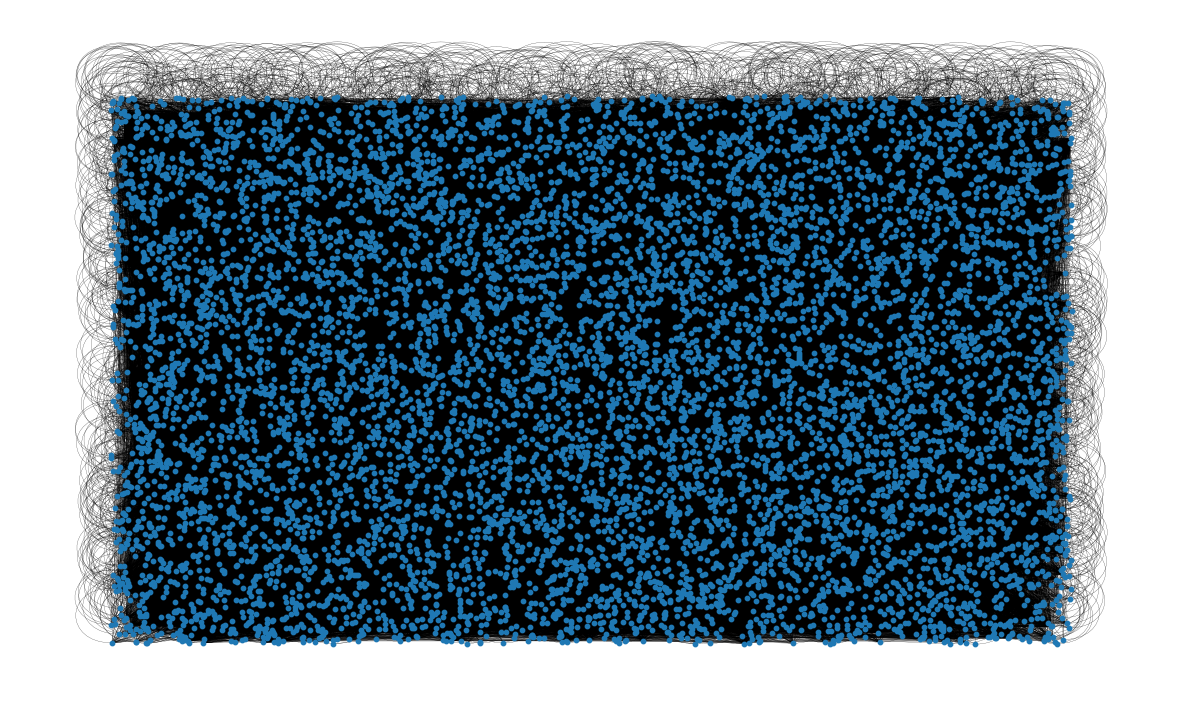

In [14]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

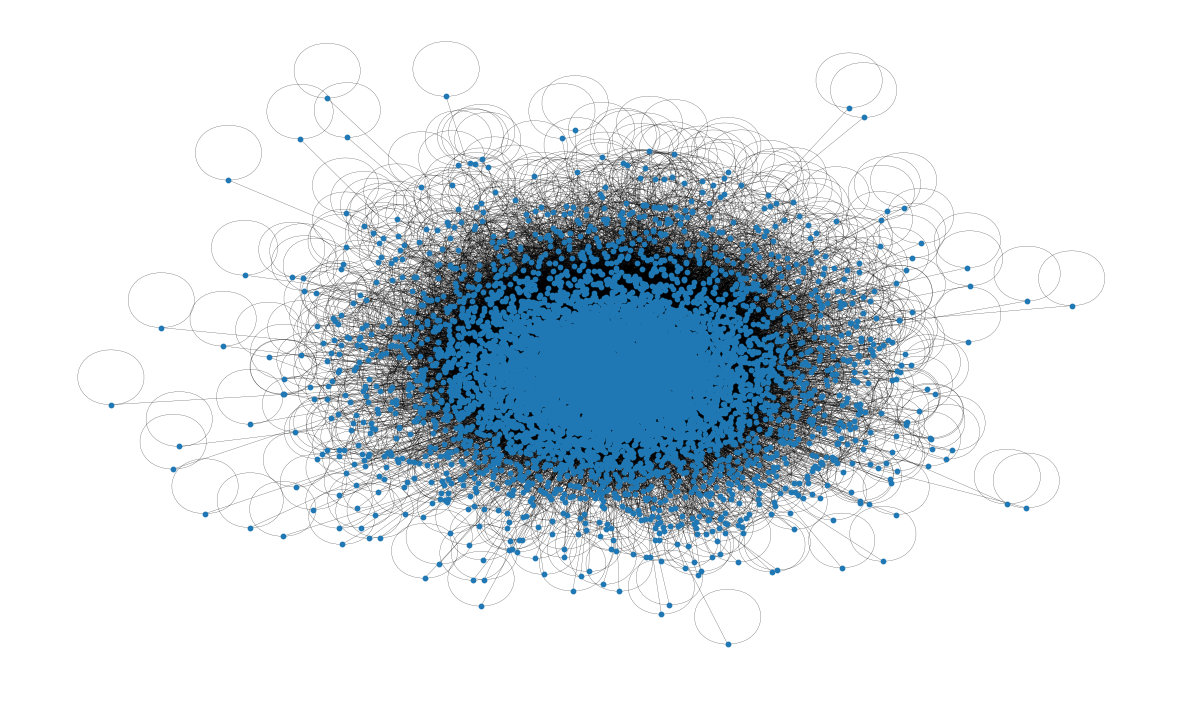

In [15]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

In [16]:
# Filtering at least 5 connections
edge_index_list_filtered = edge_index_list.groupby("start_node").filter(lambda x: len(x) > 5)
edge_index_list_filtered.head()

,start_node,end_node
0,0,9206
1,9206,0
2,0,7787
3,7787,0
4,0,2145


In [17]:
G = nx.from_pandas_edgelist(edge_index_list_filtered, "start_node", "end_node")

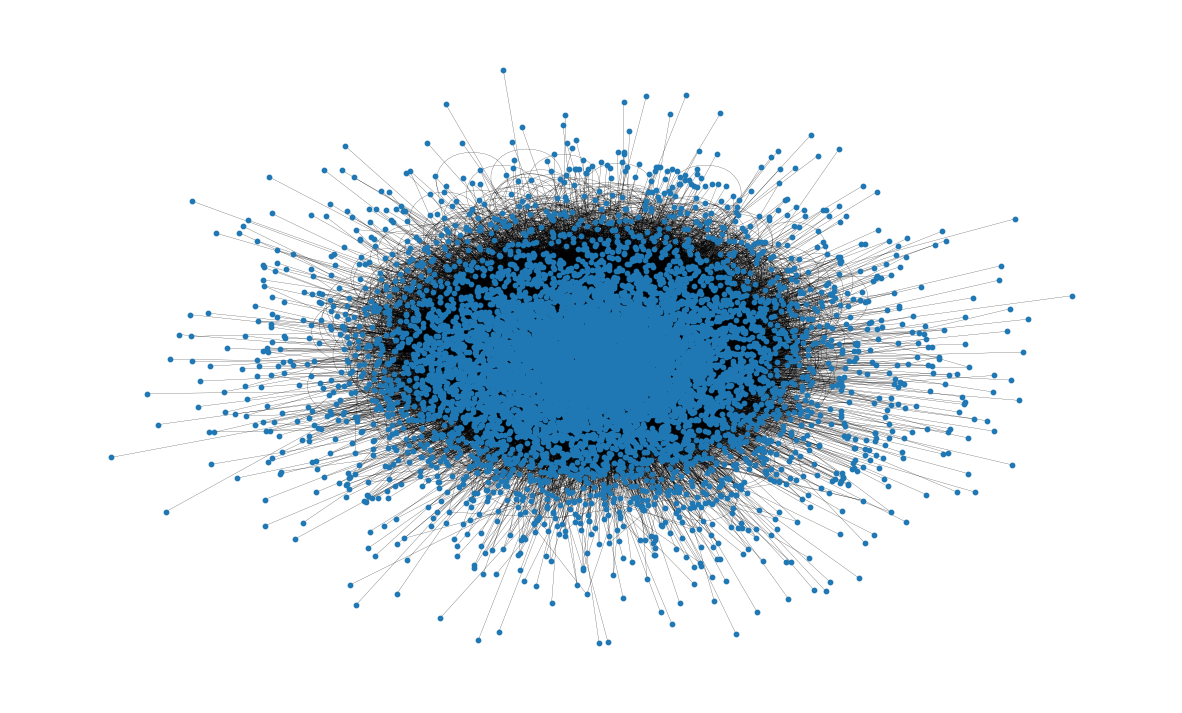

In [18]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

##Modelo base - # Graph Neural Network with Nodes Features - Yulieth

In [19]:
df_x = pd.DataFrame(data.x.numpy())
df_x['label'] = pd.DataFrame(data.y)
df_x

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,label
0,0.007061,0.007119,0.007804,0.007251,0.007298,0.007381,0.026548,0.005356,0.007791,0.007191,...,0.007046,0.007281,0.005904,0.007659,0.007284,0.005704,0.003178,0.006874,0.007576,0
1,0.005928,0.005977,0.006552,0.006097,0.006127,0.006197,0.021991,0.004496,0.006538,0.006037,...,0.006681,0.006113,0.004957,0.006430,0.006189,0.004789,0.002668,0.005771,0.006361,1
2,0.006040,0.006159,0.006663,0.006191,0.006231,0.006302,0.003514,0.004573,0.006649,0.006140,...,0.006007,0.006217,0.005041,0.006539,0.054958,0.004870,0.002713,0.005926,0.006469,1
3,0.052599,0.006441,0.007060,0.006560,0.006603,0.006678,0.043727,0.004846,0.007045,0.006506,...,0.006365,0.006588,0.005342,0.006929,0.006590,0.005161,0.002875,0.006336,0.006854,1
4,0.006083,0.006133,0.006722,0.006460,0.006473,0.006358,0.021201,0.004654,0.006708,0.006194,...,0.006724,0.006272,0.005086,0.006597,0.006379,0.004914,0.002737,0.005921,0.006526,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493,0.006041,0.006091,0.006676,0.006203,0.006244,0.006315,0.003521,0.004582,0.006754,0.006152,...,0.006019,0.006229,0.005051,0.006552,0.006231,0.004880,0.018587,0.005881,0.006482,1
9494,0.034925,0.005096,0.006113,0.006055,0.005224,0.005284,0.002946,0.023858,0.005574,0.005147,...,0.005036,0.005212,0.004226,0.005482,0.005214,0.004083,0.002274,0.004920,0.005423,1
9495,0.006439,0.006492,0.007116,0.006612,0.008469,0.006731,0.003753,0.004884,0.007101,0.006557,...,0.006416,0.007432,0.005384,0.006984,0.006642,0.005202,0.002898,0.006269,0.006909,1
9496,0.005016,0.005057,0.005544,0.005255,0.005184,0.005244,0.002923,0.003805,0.005532,0.005108,...,0.004998,0.005172,0.025138,0.047306,0.005174,0.004052,0.002257,0.004883,0.005382,0


In [20]:
import torch
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F


def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [21]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout, BatchNorm1d

class MLP(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dim_out, dropout_rate=0.5):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.bn1 = BatchNorm1d(dim_h)  # ✅ aseguramos que bn1 esté definido
        self.dropout = Dropout(p=dropout_rate)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = self.bn1(x)               # ✅ ya no da error porque está definido
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs=100, lr=0.005, weight_decay=1e-3, patience=20):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)

        self.train()
        best_val_acc = 0
        wait = 0

        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
            val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])

            if epoch % 20 == 0:
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:.2f}% | '
                      f'Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [22]:
import torch
from sklearn.model_selection import train_test_split

# Suponiendo que 'data' es un objeto tipo torch_geometric.data.Data
num_nodes = data.num_nodes

# Creamos índices para dividir en entrenamiento y test
indices = torch.randperm(num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Creamos las máscaras correctamente (1D)
data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True

# Si quieres agregar validación, puedes hacer:
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)
data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[val_idx] = True
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True

# Create MLP model
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (linear2): Linear(in_features=16, out_features=2, bias=True)
)
Epoch   0 | Train Loss: 0.699 | Train Acc: 54.42% | Val Loss: 0.70 | Val Acc: 55.47%
Epoch  20 | Train Loss: 0.605 | Train Acc: 66.41% | Val Loss: 0.62 | Val Acc: 64.95%
Epoch  40 | Train Loss: 0.593 | Train Acc: 68.02% | Val Loss: 0.63 | Val Acc: 64.53%
Early stopping triggered.

MLP test accuracy: 58.00%


# Preparacion de los datos - Zorayda

In [33]:
print(f"Min value: {data.x.min():.4f}")
print(f"Max value: {data.x.max():.4f}")
print(f"Mean: {data.x.mean():.4f}")
print(f"Norma promedio: {torch.norm(data.x, p=2, dim=1).mean():.4f}")


Min value: 0.0000
Max value: 0.1006
Mean: 0.0078
Norma promedio: 0.1265


In [34]:
from torch_geometric.transforms import NormalizeFeatures
dataset = Twitch(root='data/Twitch', name='DE', transform=NormalizeFeatures())
data = dataset[0]


In [35]:
norms = torch.norm(data.x, p=2, dim=1)
print(f"Norma promedio: {norms.mean():.4f}")  # Debería ser ≈ 1.0


Norma promedio: 0.1265


In [29]:
import pandas as pd
import torch

# Ver la forma del tensor
print(f"Shape de data.x: {data.x.shape}")  # Ej: (9498, 3170)

# Convertir las primeras 5 filas a DataFrame para explorarlas mejor
df_features = pd.DataFrame(data.x[:5].numpy())

# Mostrar las primeras filas
print("Primeras 5 filas del vector de características:")
display(df_features)


Shape de data.x: torch.Size([9498, 128])
Primeras 5 filas del vector de características:


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.007061,0.007119,0.007804,0.007251,0.007298,0.007381,0.026548,0.005356,0.007791,0.007191,...,0.008126,0.007046,0.007281,0.005904,0.007659,0.007284,0.005704,0.003178,0.006874,0.007576
1,0.005928,0.005977,0.006552,0.006097,0.006127,0.006197,0.021991,0.004496,0.006538,0.006037,...,0.006822,0.006681,0.006113,0.004957,0.006430,0.006189,0.004789,0.002668,0.005771,0.006361
2,0.006040,0.006159,0.006663,0.006191,0.006231,0.006302,0.003514,0.004573,0.006649,0.006140,...,0.006938,0.006007,0.006217,0.005041,0.006539,0.054958,0.004870,0.002713,0.005926,0.006469
3,0.052599,0.006441,0.007060,0.006560,0.006603,0.006678,0.043727,0.004846,0.007045,0.006506,...,0.007352,0.006365,0.006588,0.005342,0.006929,0.006590,0.005161,0.002875,0.006336,0.006854
4,0.006083,0.006133,0.006722,0.006460,0.006473,0.006358,0.021201,0.004654,0.006708,0.006194,...,0.007000,0.006724,0.006272,0.005086,0.006597,0.006379,0.004914,0.002737,0.005921,0.006526


In [38]:
#división dataset train y test
from sklearn.model_selection import train_test_split
import torch

# Total de nodos
num_nodes = data.num_nodes

# Crear índices aleatorios
indices = torch.randperm(num_nodes)

# Dividir: 80% entrenamiento, 20% prueba
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

# Inicializar máscaras
data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# Asignar los nodos correspondientes
data.train_mask[train_idx] = True
data.test_mask[test_idx] = True

# Verificar la cantidad de nodos en cada conjunto
print(f"Nodos de entrenamiento: {data.train_mask.sum().item()}")
print(f"Nodos de prueba: {data.test_mask.sum().item()}")


Nodos de entrenamiento: 7598
Nodos de prueba: 1900


# Modelo 1 - Yulieth

# Modelo 2 - Zorayda  - GCN

In [40]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)


# Crear el modelo
model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc_train = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    acc_test = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    return acc_train, acc_test


for epoch in range(1, 101):
    loss = train()
    acc_train, acc_test = test()
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3} | Loss: {loss:.4f} | Train Acc: {acc_train*100:.2f}% | Test Acc: {acc_test*100:.2f}%")


Epoch   1 | Loss: 0.6917 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  10 | Loss: 0.6646 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  20 | Loss: 0.6633 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  30 | Loss: 0.6624 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  40 | Loss: 0.6616 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  50 | Loss: 0.6603 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  60 | Loss: 0.6585 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  70 | Loss: 0.6563 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  80 | Loss: 0.6541 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch  90 | Loss: 0.6519 | Train Acc: 60.52% | Test Acc: 60.21%
Epoch 100 | Loss: 0.6495 | Train Acc: 60.58% | Test Acc: 60.42%


# Modelo 3 - Alejandro